In [251]:
import random
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

NAMES = [name.strip() for name in open("names.txt", "r").readlines()]

def name_to_tensor(name):
    return torch.tensor([0]+[1 + ord(c) - ord("a") for c in name]+[0])
def tensor_to_name(tensor):
    return "".join([chr(c + ord("a")-1) for c in tensor[1:-1]])

def sliding_mean(x: torch.Tensor, window: int) -> torch.Tensor:
    x = x.float()
    prefix = torch.cat((x.new_zeros(1), x.cumsum(dim=0)))
    return (prefix[window:] - prefix[:-window]) / window

In [ ]:
import matplotlib.pyplot as plt
import random

inputX = []
inputY = []

CONTEXT_WIDTH = 3

DEVICE = "cpu"
#DEVICE = "mps"
#DEVICE = "cuda"

SEED = 42
random_generator = torch.Generator(device=DEVICE).manual_seed(SEED)


class Model:
    def __init__(self, contextWidth = CONTEXT_WIDTH, embeddingDim = 2, innerLayer = 120):
        self.contextWidth = contextWidth
        self.embeddingDim = embeddingDim
        self.innerLayer = innerLayer
        self.reset()
    
    def parameters(self):
        return [self.C, self.W1, self.B1, self.W2, self.B2]

    def reset(self):
        random_generator.manual_seed(SEED)
        self.C = torch.randn([27,self.embeddingDim], device=DEVICE, requires_grad=True, generator=random_generator)
        self.W1 = torch.randn([self.embeddingDim * self.contextWidth, self.innerLayer], device=DEVICE, requires_grad=True, generator=random_generator)
        self.B1 = torch.randn([self.innerLayer], device=DEVICE, requires_grad=True, generator=random_generator)
        self.W2 = torch.randn([self.innerLayer,27], device=DEVICE, requires_grad=True, generator=random_generator)
        self.B2 = torch.randn([27], device=DEVICE, requires_grad=True, generator=random_generator)

    def forwardPass(self,inputs):
        emb = self.C[inputs]
        R = emb.view(-1, self.embeddingDim * self.contextWidth) @ self.W1 + self.B1
        R = torch.tanh(R)
        R = R @ self.W2 + self.B2
        return R

    def nnLoss(self, inputs, targets):
        R = self.forwardPass(inputs)
        return F.cross_entropy(R, targets)

    def getProbabilities(self, inputs):
        R = self.forwardPass(inputs)
        return F.softmax(R, dim=1)
        
#NN = Model()

# Prepare test sets

def prepareTestSets(names):
    X = []
    Y = []
    for name in names:
        t = name_to_tensor(name)
        x = [0] * NN.contextWidth

        for i in range(0, len(t)-1):
            x = x[1:] + [t[i].item()]
            X.append(x)
            Y.append(t[i+1].item())
    return (torch.tensor(X, device=DEVICE), torch.tensor(Y, device=DEVICE))

random.seed(SEED)
random.shuffle(NAMES)

names80p = int(len(NAMES)*0.8)
names90p = int(len(NAMES)*0.9)

inputX_train, inputY_train = prepareTestSets(NAMES[:names80p])
inputX_val, inputY_val = prepareTestSets(NAMES[names80p:names90p])
inputX_test, inputY_test = prepareTestSets(NAMES[names90p:])


#Training 

def doTraining(
    iterations = 1000, 
    batchSize = 32, 
    learningRate = 0.1, 
    learningRateDecay = 0.1, 
    learningRateDecaySize = 0.3, 
    varSet = False, 
    printEvery = -1, 
    reset = False,
    losses = None,
    addVelocity = False,
    velocityDecay = 0.9):
    
    trainX = inputX_val if varSet else inputX_train
    trainY = inputY_val if varSet else inputY_train
    velocity = []
    for param in NN.parameters():
        velocity.append(torch.zeros_like(param))
    if reset: NN.reset()
    for iteration in range(iterations):
        idx = torch.randint(0, len(trainX), (batchSize,), device=DEVICE, generator=random_generator)
        R = NN.nnLoss(trainX[idx], trainY[idx])
        R.backward()
        with torch.no_grad():
            for pi, param in enumerate(NN.parameters()):
                if addVelocity:
                    velocity[pi] = velocityDecay * velocity[pi] + param.grad
                    param -= (learningRateDecay if ((1.0 - iteration/iterations)<learningRateDecaySize) else 1.0) * learningRate * velocity[pi]
                else:
                    param -= (learningRateDecay if ((1.0 - iteration/iterations)<learningRateDecaySize) else 1.0) * learningRate * param.grad
                param.grad = None
        if printEvery!=-1 and iteration%printEvery == 0: print(iteration, R.item())
        if losses is not None: losses.append(R.log10().item())
    return (NN.nnLoss(inputX_test, inputY_test).item(), NN.nnLoss(trainX, trainY).item())

# 2.227020502090454
#NN = Model(embeddingDim=2, innerLayer=300)

#2.1205410957336426
#NN = Model(embeddingDim=4, innerLayer=200)

#2.1233456134796143
#NN = Model(embeddingDim=6, innerLayer=200)

#2.100982189178467
NN = Model(embeddingDim=10, innerLayer=200)

#batchSizes = [2**x for x in range(4,11)]
#losses = [doTraining(iterations=100, batchSize=batchSize, varSet=True, reset=True)[0] for batchSize in batchSizes]
#plt.plot(batchSizes, losses)
batchSize = 512

#learningRate =[-0.5 + x*0.05 for x in range(0,20)]
#losses = [doTraining(iterations=100, batchSize=batchSize, learningRate=10**lr, varSet=True, reset=True)[0] for lr in learningRate]
#plt.plot(learningRate, losses)
learningRate = 10**(0.1)

print(f"batchSize: {batchSize}")
print(f"learningRate: {learningRate}")

NN.reset()
losses = []
def plotLosses(starting_at, smoothing=1):
    plt.plot(
        [starting_at+smoothing-1+x for x in range(len(losses)-starting_at-smoothing+1)], 
        sliding_mean(torch.tensor(losses[starting_at:]), smoothing))

batchSize: 512
learningRate: 1.2589254117941673


0 1.9734121561050415
5000 1.9089486598968506


(2.1009788513183594, 2.000636100769043)

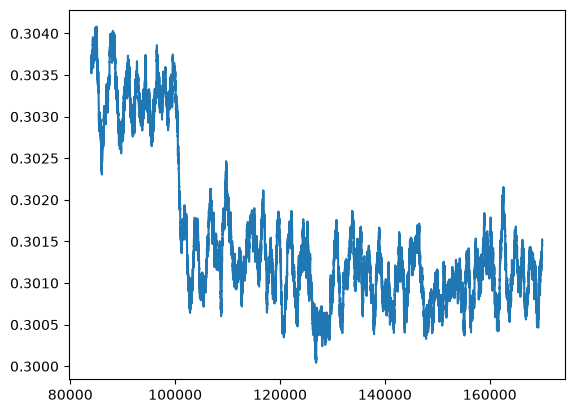

In [294]:

r = doTraining(
    iterations=10000, batchSize=batchSize, learningRate=learningRate*0.0001, 
    learningRateDecay=0.0, printEvery=5000,
    losses=losses)
    #addVelocity=True)

plotLosses(starting_at=83*1000, smoothing=1000)
r

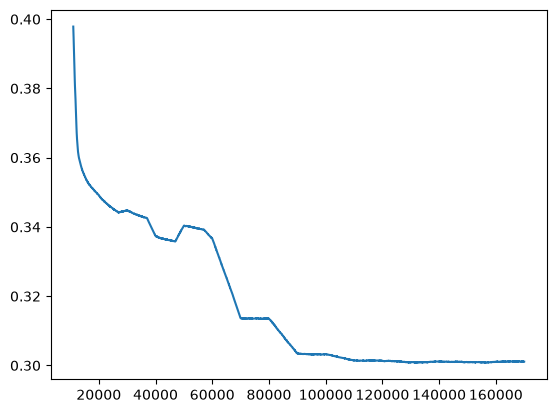

In [295]:
def plotLosses(starting_at, smoothing=1):
    plt.plot(
        [starting_at+smoothing-1+x for x in range(len(losses)-starting_at-smoothing+1)], 
        sliding_mean(torch.tensor(losses[starting_at:]), smoothing))


plotLosses(starting_at=1000, smoothing=10000)

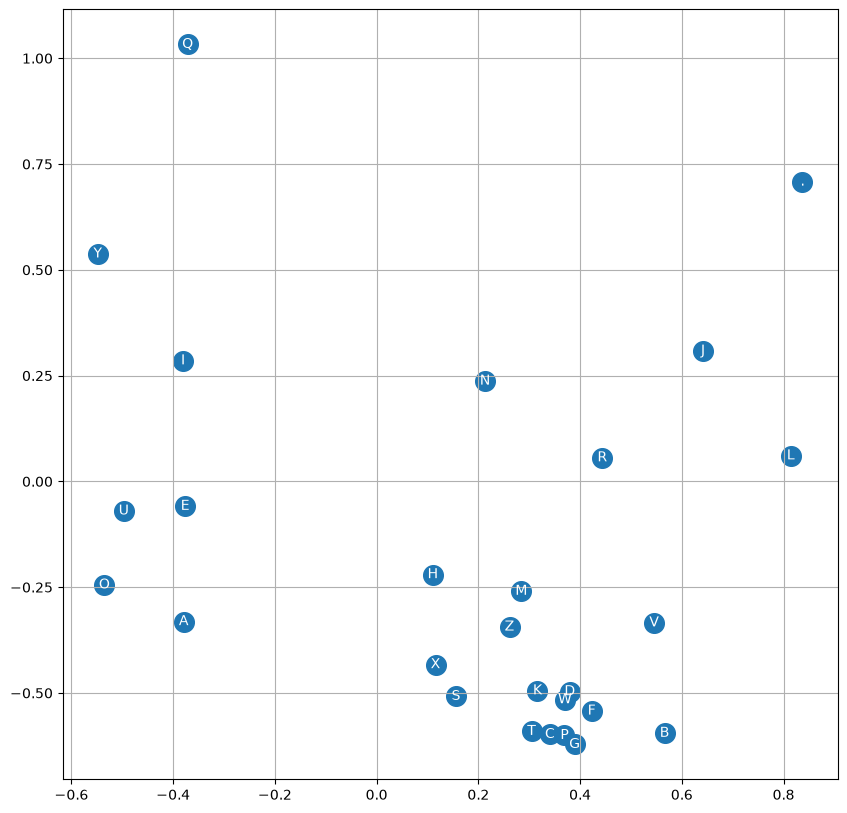

In [164]:
plt.figure(figsize=(10, 10))
plt.scatter(NN.C[:,0].data, NN.C[:,1].data, s=200)
for i in range(27):
    plt.text(NN.C[i,0].data, NN.C[i,1].data, "." if i==0 else chr(i-1+ord("A")), ha="center", va="center", color = 'white')
plt.grid('minor')


In [296]:

def genWord():
    res = [0]*NN.contextWidth
    
    while True:
        b = NN.getProbabilities(res[-NN.contextWidth:]).multinomial(num_samples=1, replacement=True).item()
        res.append(b)
        if b == 0:
            break;

    return tensor_to_name(res[NN.contextWidth-1:])


print("loss:", NN.nnLoss(inputX_test, inputY_test).item())

for i in range(20):
    print(genWord())

# Leun    

loss: 2.1009788513183594
kaisi
giove
charmondrea
dayvisidd
blaya
kard
elie
rhye
don
ansy
nan
nasantuckaria
dorenleia
mohenah
ice
kael
elin
adaira
ana
siyah
